In [13]:
import osmnx as ox
import networkx as nx
import numpy as np

In [14]:
import sys
sys.path.append('.')
from routing import generate_loop_route, generate_loop_route_tuned

In [15]:
start_lat, start_lon = 18.5204, 73.8567
target_distance_m = 5000

search_radius = target_distance_m * 0.8  # generous padding
G = ox.graph_from_point((start_lat, start_lon), dist=search_radius, network_type='walk')
print(f"Graph loaded: {len(G.nodes)} nodes, {len(G.edges)} edges")

Graph loaded: 12668 nodes, 33452 edges


In [16]:
edge_types = []
for u, v, data in G.edges(data=True):
    h = data.get('highway', 'unknown')
    if isinstance(h, list):
        h = ','.join(h)  # join multi-value tags into one string
    edge_types.append(h)

from collections import Counter
print(Counter(edge_types).most_common(20))

[('residential', 14158), ('service', 5816), ('tertiary', 3878), ('footway', 2598), ('primary', 2332), ('secondary', 1786), ('trunk', 1066), ('living_street', 1058), ('track', 134), ('path', 130), ('trunk_link', 84), ('primary_link', 76), ('secondary_link', 48), ('steps', 42), ('footway,steps', 38), ('living_street,residential', 32), ('busway', 24), ('residential,service', 22), ('pedestrian', 20), ('steps,footway', 20)]


In [17]:
import networkx as nx

# Keep only the largest connected component (removes disconnected junk fragments)
largest_cc = max(nx.weakly_connected_components(G), key=len)
G = G.subgraph(largest_cc).copy()
print(f"Trimmed graph to {len(G.nodes)} nodes, {len(G.edges)} edges")

Trimmed graph to 12668 nodes, 33452 edges


In [18]:
from routing import generate_loop_route
route, dist = generate_loop_route(G, start_lat, start_lon, target_distance_m)
print(dist)

4946.313563340325


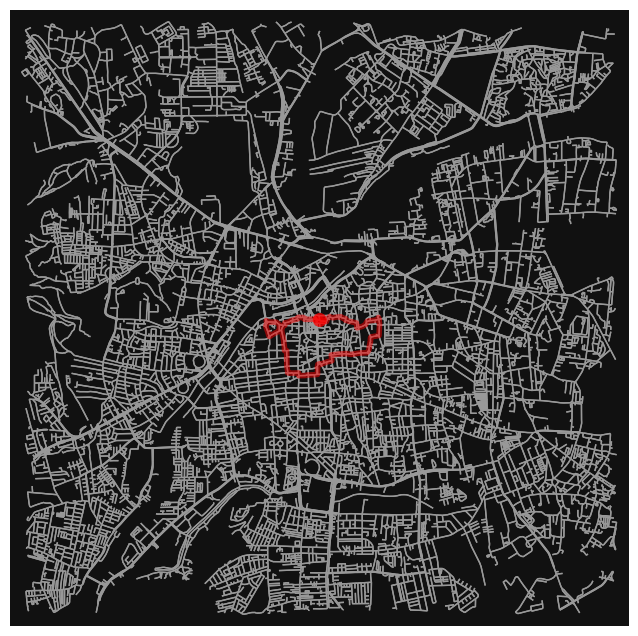

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [19]:
ox.plot_graph_route(G, route, route_linewidth=4, node_size=0, figsize=(8, 8))

In [20]:
ox.save_graphml(G, filepath="pune_graph.graphml")
print("Saved graph to pune_graph.graphml")

Saved graph to pune_graph.graphml


In [21]:
import sys
sys.path.append('.')
import importlib
import routing
importlib.reload(routing)  # picks up your latest saved routing.py

route, dist = routing.generate_loop_route(G, start_lat, start_lon, target_distance_m=5000)
print(f"Route length: {len(route)} nodes")
print(f"First node: {route[0]}")
print(f"Last node: {route[-1]}")
print(f"Start node should be: {ox.distance.nearest_nodes(G, start_lon, start_lat)}")
print(f"Does route close? {route[0] == route[-1]}")
print(f"Total distance: {dist:.0f}m")

Route length: 103 nodes
First node: 5423916623
Last node: 5423916623
Start node should be: 5423916623
Does route close? True
Total distance: 4946m


In [22]:
import sys
sys.path.append('.')
import importlib, routing
importlib.reload(routing)

route, dist = routing.generate_loop_route(G, start_lat, start_lon, target_distance_m=5000)

# Check each edge's real length and whether it has proper geometry
for i in range(len(route) - 1):
    u, v = route[i], route[i+1]
    edge_data = G.get_edge_data(u, v)
    if edge_data is None:
        print(f"Edge {u}->{v}: NO EDGE DATA (problem!)")
        continue
    for key, data in edge_data.items():
        length = data.get('length', 'unknown')
        has_geometry = 'geometry' in data
        highway_type = data.get('highway', 'unknown')
        if length != 'unknown' and length > 100:  # flag suspiciously long single edges
            print(f"Edge {u}->{v}: length={length:.0f}m, highway={highway_type}, has_geometry={has_geometry}")

Edge 633121771->2999866974: length=103m, highway=tertiary, has_geometry=True
Edge 10539089588->633121826: length=115m, highway=tertiary, has_geometry=True
Edge 633121778->1911004828: length=144m, highway=residential, has_geometry=True
Edge 248435609->673356557: length=104m, highway=tertiary, has_geometry=True
Edge 678440477->678440485: length=131m, highway=residential, has_geometry=True
Edge 245646818->2266580478: length=113m, highway=residential, has_geometry=False
Edge 2266580494->2266580505: length=153m, highway=residential, has_geometry=True
Edge 2289294128->2266580504: length=107m, highway=residential, has_geometry=True
Edge 678451080->678451085: length=106m, highway=residential, has_geometry=True
